# Dataset

In [1]:
# dataset.py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class DrivingDataset(Dataset):
    def __init__(self, npz_path: str):
        super().__init__()
        D = np.load(npz_path)

        # ---- Controls: [B,200] = (100 vel + 100 steer) ----
        controls = D["controls"].astype(np.float32)
        self.controls = controls

        # ---- Ego (8) + Lane (2) -> Ego(10) ----
        ego = D["ego"].astype(np.float32)
        x, y, vx, vy, ax, ay, psi, psidot = [ego[:, i] for i in range(8)]

        lane = D["lane"].astype(np.float32)
        y_lb, y_ub = lane[:, 0], lane[:, 1]

        ego_feats = np.stack(
            [x, y, vx, vy, ax, ay, psi, psidot, y_lb, y_ub], axis=1
        ).astype(np.float32)

        # ---- Obstacles: obs [B,56] -> [B,7,8] -> PN features [B,8,8] ----
        obs_flat = D["obs"].astype(np.float32)
        B = obs_flat.shape[0]
        N_obs, FEATS_PER_OBS = 8, 7

        obs_blocks = obs_flat.reshape(B, FEATS_PER_OBS, N_obs)
        x_o, y_o, vx_o, vy_o, psi_o, dimx_o, dimy_o = [obs_blocks[:, i, :] for i in range(7)]

        relx   = x_o - x[:, None]
        rely   = y_o - y[:, None]
        cospsi = np.cos(psi_o)
        sinpsi = np.sin(psi_o)

        obs_feats = np.stack(
            [relx, rely, vx_o, vy_o, cospsi, sinpsi, dimx_o, dimy_o], axis=2
        ).astype(np.float32)  

        # ---- Normalization (dataset-wide) ----
        self.B     = B
        self.N_obs = N_obs

        self.ego_mean = ego_feats.mean(axis=0)
        self.ego_std  = ego_feats.std(axis=0) + 1e-6

        obs_flat_8 = obs_feats.reshape(self.B * self.N_obs, -1)
        self.obs_mean = obs_flat_8.mean(axis=0)
        self.obs_std  = obs_flat_8.std(axis=0) + 1e-6

        self.ego_feats = ego_feats
        self.obs_feats = obs_feats

    def __len__(self):
        return self.B

    def __getitem__(self, i: int):
        # Normalize ego & obstacles
        ego = (self.ego_feats[i] - self.ego_mean) / self.ego_std          
        obs = (self.obs_feats[i] - self.obs_mean) / self.obs_std          

        # Controls: first 100 velocity, next 100 steering
        vel   = self.controls[i, :100]
        steer = self.controls[i, 100:200]
        y = np.stack([vel, steer], axis=0).astype(np.float32)              

        return torch.from_numpy(ego), torch.from_numpy(obs), torch.from_numpy(y)

def make_loader(npz_path, batch_size=128, shuffle=True, num_workers=4, pin_memory=True):
    ds = DrivingDataset(npz_path)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
        drop_last=False
    )
    return ds, dl


# Training

In [ ]:

import os, time, math, torch
from torch.utils.data import DataLoader, random_split
from model_6 import PolicySeqFlow


# ---- Config ----
DATA_FILE   = "./data_train.npz"
SAVE_DIR    = "./checkpoints"
BATCH_SIZE  = 256
VAL_SPLIT   = 0.10
LR          = 1e-4
EPOCHS      = 300
CLIP        = 5.0
SEED        = 42  # for dataset split
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(SAVE_DIR, exist_ok=True)
torch.manual_seed(SEED)

# ---- Split dataset + loaders  ----
ds_full = DrivingDataset(DATA_FILE)
H       = ds_full.controls.shape[1] // 2  # 200 -> H=100

n_total = len(ds_full)
n_val   = max(1, int(VAL_SPLIT * n_total))
n_train = n_total - n_val
tr_ds, va_ds = random_split(ds_full, [n_train, n_val],
                            generator=torch.Generator().manual_seed(SEED))

train_dl = DataLoader(
    tr_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True,
    persistent_workers=True, drop_last=False
)
val_dl = DataLoader(
    va_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
    persistent_workers=True, drop_last=False
)

# ---- Model ----
model = PolicySeqFlow(ctx_dim=128, horizon=H, hidden=256).to(DEVICE)

# ----- Loss function -----
def _fm_batch_prep(y, device):
    """y:[B,2,H] -> (t:[B,1], x_t:[B,2H], dx_t:[B,2H])"""
    B, _, H = y.shape
    x1 = y.permute(0, 2, 1).reshape(B, 2*H)      # [B,2H] ---- GD
    x0 = torch.randn_like(x1)                     # [B,2H]-----Noise
    t  = torch.rand(B, 1, device=device)         # [B,1]------Random t
    x_t  = (1.0 - t) * x0 + t * x1               # [B,2H]
    dx_t = (x1 - x0)                              # [B,2H]---- loss
    return t, x_t, dx_t, H

def train_epoch_fb(model, optimizer, train_dl, device, clip=5.0):
    model.train()
    total = 0.0
    for ego, obs, y in train_dl:
        ego = ego.to(device, non_blocking=True)   # [B,10]------Ego
        obs = obs.to(device, non_blocking=True)   # [B,8,8]----Obs
        y   = y.to(device, non_blocking=True)     # [B,2,H]------Controls

        t, x_t, dx_t, H_ = _fm_batch_prep(y, device) # loss
        

        ctx  = model.context(ego, obs)            # [B,C]-----Obs+Ego -> Context
        pred = model.fm(t, x_t, ctx)              # [B,2H]-----Flow model pred

        loss = torch.mean((pred - dx_t)**2)       

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total += loss.item()
    return total / max(1, len(train_dl))

@torch.no_grad()
def eval_epoch_fb(model, val_dl, device):
    model.eval()
    total = 0.0
    for ego, obs, y in val_dl:
        ego = ego.to(device, non_blocking=True)
        obs = obs.to(device, non_blocking=True)
        y   = y.to(device, non_blocking=True)

        t, x_t, dx_t, H_ = _fm_batch_prep(y, device)

        ctx  = model.context(ego, obs)
        pred = model.fm(t, x_t, ctx)

        loss = torch.mean((pred - dx_t)**2)       # FB val loss
        total += loss.item()
    return total / max(1, len(val_dl))

def train_like_fb(model,
                  train_dl,
                  val_dl,
                  epochs=EPOCHS,
                  lr=LR,
                  device=DEVICE,
                  clip=CLIP,
                  ckpt_best_path=os.path.join(SAVE_DIR, "fb_best.pt"),
                  ckpt_last_path=os.path.join(SAVE_DIR, "fb_last.pt")):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val = math.inf

    for ep in range(1, epochs+1):
        t0 = time.time()
        tr = train_epoch_fb(model, opt, train_dl, device, clip=clip)
        va = eval_epoch_fb(model, val_dl, device)
        print(f"Epoch {ep:03d} | train {tr:.6f} | val {va:.6f} | {time.time()-t0:.1f}s")

        if va < best_val:
            best_val = va
            torch.save(model.state_dict(), ckpt_best_path)

        torch.save(model.state_dict(), ckpt_last_path)

    return model

# ---- Run training ----
model = train_like_fb(model, train_dl, val_dl)
print("Done. Best/last checkpoints saved in:", SAVE_DIR)


Epoch 001 | train 1.382491 | val 1.117901 | 10.3s
Epoch 002 | train 1.043482 | val 0.977636 | 10.0s
Epoch 003 | train 0.939638 | val 0.900004 | 9.8s
Epoch 004 | train 0.866668 | val 0.835011 | 9.9s
Epoch 005 | train 0.811766 | val 0.783215 | 9.9s
Epoch 006 | train 0.764242 | val 0.741720 | 9.9s
Epoch 007 | train 0.726391 | val 0.707820 | 9.8s
Epoch 008 | train 0.692719 | val 0.681572 | 10.0s
Epoch 009 | train 0.667858 | val 0.671553 | 10.1s
Epoch 010 | train 0.644360 | val 0.629292 | 9.9s
Epoch 011 | train 0.623156 | val 0.615854 | 10.0s
Epoch 012 | train 0.603953 | val 0.590593 | 9.8s
Epoch 013 | train 0.585230 | val 0.574824 | 9.9s
Epoch 014 | train 0.568817 | val 0.556838 | 9.9s
Epoch 015 | train 0.553916 | val 0.544215 | 9.7s
Epoch 016 | train 0.540532 | val 0.529720 | 9.9s
Epoch 017 | train 0.526256 | val 0.516616 | 9.7s
Epoch 018 | train 0.512120 | val 0.501535 | 9.7s
Epoch 019 | train 0.500053 | val 0.490419 | 9.8s
Epoch 020 | train 0.488290 | val 0.478919 | 9.6s
Epoch 021 | tra

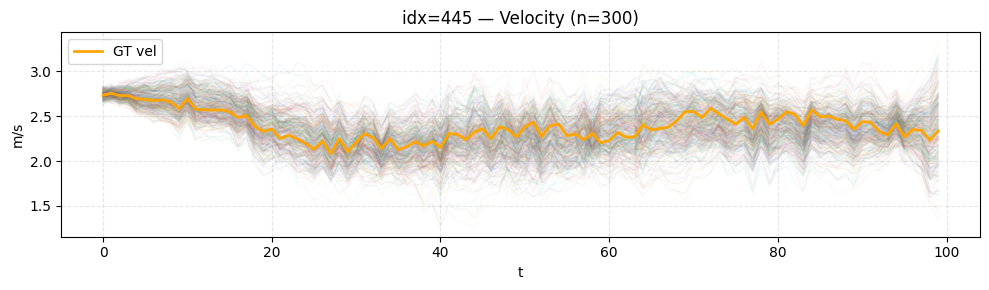

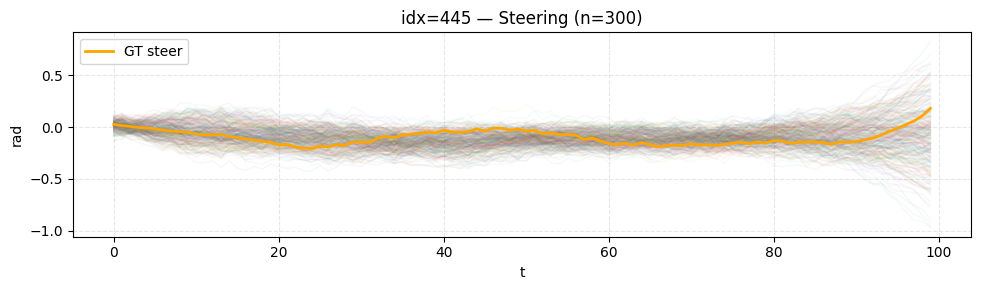

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random
from model_6 import PolicySeqFlow

@torch.no_grad()
def sample_sequences(model, ego, obs, n_samples=300, n_int=10, sigma=0.8,
                     clamp_quantiles=None):
    """
    Returns: [n_samples, B, 2, H]
    Works with FMSeq (trajectory head): x ∈ R^{2H}, not per-timestep.
    """
    device = next(model.parameters()).device
    model.eval()

    ego, obs = ego.to(device), obs.to(device)     # From dataset
    ctx = model.context(ego, obs)                 # [B, C]
    B = ctx.size(0); H = getattr(model, "horizon", 100) # gives H=100 from model

    ts = torch.linspace(0.0, 1.0, n_int + 1, device=device) # Time steps

    if clamp_quantiles is not None:              # optional vel/steer clamp
        v_lo, v_hi, s_lo, s_hi = clamp_quantiles

    samples = []
    for _ in range(n_samples):
        # start from noise in trajectory space
        x = torch.randn(B, 2 * H, device=device) * sigma  # [B,2H]

        for i in range(n_int):
            t0, t1 = ts[i], ts[i+1]
            x = model.fm.step(x, t0, t1, ctx)             # Heun midpoint inside

            if clamp_quantiles is not None: # optional vel/steer clamp
                xv = x.view(B, H, 2)                      # [B,H,2] -> clamp per channel
                xv[..., 0] = xv[..., 0].clamp(v_lo, v_hi) # optional velocity clamp
                xv[..., 1] = xv[..., 1].clamp(s_lo, s_hi) # optional steering clamp
                x = xv.view(B, 2 * H)

        x_seq = x.view(B, H, 2).permute(0, 2, 1).contiguous()  # [B,2,H]
        samples.append(x_seq)

    return torch.stack(samples, dim=0)  # [n_samples, B, 2, H]


@torch.no_grad()
def plot_300_predictions_no_mean(model, ds, idx=0, n_samples=300, n_int=10, sigma=1.5,
                                 clamp_quantiles=None):
    """
    Draw 300 sampled sequences (thin) + GT (bold), no mean curve.
    """
    ego, obs, y = ds[idx]                         
    H = y.shape[-1] # Number of timesteps
    device = next(model.parameters()).device # gives weights and bias

    ego = ego.unsqueeze(0).to(device)  # add batch dimension
    obs = obs.unsqueeze(0).to(device)  # add batch dimension
    y_np = y.numpy()
    t = np.arange(H) # arrange of timesteps

    # Sample from FMSeq trajectory head
    S = sample_sequences(model, ego, obs, n_samples=n_samples, n_int=n_int,
                         sigma=sigma, clamp_quantiles=clamp_quantiles)  
    S = S[:, 0].cpu().numpy()                     

    # --- Velocity ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 0], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[0], label="GT vel", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Velocity (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("m/s"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

    # --- Steering ---
    plt.figure(figsize=(10, 3))
    for k in range(n_samples):
        plt.plot(t, S[k, 1], alpha=0.05, linewidth=1)
    plt.plot(t, y_np[1], label="GT steer", linewidth=2, color="orange")
    plt.title(f"idx={idx} — Steering (n={n_samples})")
    plt.xlabel("t"); plt.ylabel("rad"); plt.grid(True, ls="--", alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

model = PolicySeqFlow(ctx_dim=128, horizon=100, hidden=256)


model.load_state_dict(torch.load("checkpoints/fb_best.pt", map_location="cuda"))


model.eval()

ds = DrivingDataset("./data_train.npz")
plot_300_predictions_no_mean(model, ds, idx=445, n_samples=300, n_int=512, sigma=0.8)
